In [1]:
from google.colab import drive
drive.mount('/content/drive')
#

Mounted at /content/drive


In [ ]:
import dask_cudf
import cudf
import pandas as pd
import numpy as np
import joblib

print("==================================================")
print("🛠️ 1. Read data and fix dates on GPU")
print("==================================================")

raw_data_path = "/content/drive/MyDrive/Full_Taxi_data/merged_taxi_data_v3.parquet"
cols_needed = ['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'PULocationID', 'DOLocationID']

ddf_raw = dask_cudf.read_parquet(raw_data_path, columns=cols_needed)

# Fix dates (avoid 1970 issue)
sec_in_6h = 6 * 3600
ddf_raw['pickup_bucket_6H'] = (ddf_raw['tpep_pickup_datetime'].astype('datetime64[s]').astype('int64') // sec_in_6h * sec_in_6h).astype('datetime64[s]')
ddf_raw['dropoff_bucket_6H'] = (ddf_raw['tpep_dropoff_datetime'].astype('datetime64[s]').astype('int64') // sec_in_6h * sec_in_6h).astype('datetime64[s]')

print("⏳Aggregation...")
ddf_pickups = ddf_raw.groupby(['PULocationID', 'pickup_bucket_6H']).size().reset_index()
ddf_pickups.columns = ['zone_id', 'time_bucket_6H', 'pickup_count']

ddf_dropoffs = ddf_raw.groupby(['DOLocationID', 'dropoff_bucket_6H']).size().reset_index()
ddf_dropoffs.columns = ['zone_id', 'time_bucket_6H', 'dropoff_count']

# Convert for Pandas to easily complete feature engineering
df_pickups = ddf_pickups.compute().to_pandas()
df_dropoffs = ddf_dropoffs.compute().to_pandas()

print("==================================================")
print("🛠️ 2. Feature Engineering")
print("==================================================")

df_supply_demand = pd.merge(df_pickups, df_dropoffs, on=['zone_id', 'time_bucket_6H'], how='outer').fillna(0)
df_supply_demand = df_supply_demand.sort_values(['zone_id', 'time_bucket_6H']).reset_index(drop=True)

df_supply_demand['net_flow'] = df_supply_demand['dropoff_count'] - df_supply_demand['pickup_count']
df_supply_demand['activity_ratio'] = df_supply_demand['pickup_count'] / (df_supply_demand['dropoff_count'] + 1)

# Synthesize the current target
condition_shortage = (df_supply_demand['pickup_count'] > (df_supply_demand['dropoff_count'] * 1.2)) & (df_supply_demand['pickup_count'] > 10)
df_supply_demand['is_stockout_current'] = np.where(condition_shortage, 1, 0)

#Feature Engineering (Lags) -> Here df_final_stockout is synthesized
df_supply_demand['target_stockout_next_6h'] = df_supply_demand.groupby('zone_id')['is_stockout_current'].shift(-1)
df_supply_demand['lag_1_pickup'] = df_supply_demand.groupby('zone_id')['pickup_count'].shift(1).fillna(0)
df_supply_demand['lag_1_dropoff'] = df_supply_demand.groupby('zone_id')['dropoff_count'].shift(1).fillna(0)
df_supply_demand['lag_1_net_flow'] = df_supply_demand.groupby('zone_id')['net_flow'].shift(1).fillna(0)
df_supply_demand['hour'] = df_supply_demand['time_bucket_6H'].dt.hour
df_supply_demand['day_of_week'] = df_supply_demand['time_bucket_6H'].dt.dayofweek
df_supply_demand['is_weekend'] = df_supply_demand['day_of_week'].isin([5, 6]).astype(int)

df_final_stockout = df_supply_demand.dropna().reset_index(drop=True)

print("==================================================")
print("🔗 3. Demand forecast (ML 1) and final merge")
print("==================================================")

demand_model_path = "/content/drive/MyDrive/Full_Taxi_data/lgbm_demand_model_ml1(6h).pkl"
demand_model = joblib.load(demand_model_path)

demand_features = [
    'PULocationID', 'pickup_hour', 'day_of_week', 'is_weekend',
    'temp_c', 'rain_mm', 'is_rain', 'weather_code', 'is_holiday',
    'lag_1_6h', 'lag_2_6h', 'lag_4_6h', 'rolling_mean_24h'
]
cat_cols = ['PULocationID', 'pickup_hour', 'day_of_week', 'is_weekend', 'is_rain', 'weather_code', 'is_holiday']

demand_data_path = "/content/drive/MyDrive/Full_Taxi_data/processed_taxi_data_ML1(6h).parquet"
cols_to_load = demand_features + ['time_bucket_6H']
ddf_processed = dask_cudf.read_parquet(demand_data_path, columns=cols_to_load)

df_for_prediction = ddf_processed.compute().to_pandas()
for col in cat_cols:
    df_for_prediction[col] = df_for_prediction[col].astype('category')

print("🤖 Expect demand for the next 6 hours...")
df_for_prediction['forecasted_demand_6h'] = demand_model.predict(df_for_prediction[demand_features])
df_for_prediction['forecasted_demand_6h'] = np.maximum(0, df_for_prediction['forecasted_demand_6h'])

# Return to the GPU for final integration
cdf_demand_subset = cudf.DataFrame({
    'time_bucket_6H': df_for_prediction['time_bucket_6H'],
    'zone_id': df_for_prediction['PULocationID'],
    'forecasted_demand_6h': df_for_prediction['forecasted_demand_6h'],
    'temp_c': df_for_prediction['temp_c'],
    'rain_mm': df_for_prediction['rain_mm'],
    'is_rain': df_for_prediction['is_rain'],
    'weather_code': df_for_prediction['weather_code'],
    'is_holiday': df_for_prediction['is_holiday']
})

cdf_final_stockout = cudf.DataFrame(df_final_stockout)

print("🔗 Merge on GPU...")
cdf_master_stockout = cdf_final_stockout.merge(
    cdf_demand_subset,
    on=['zone_id', 'time_bucket_6H'],
    how='inner'
)

df_master_stockout_pandas = cdf_master_stockout.to_pandas()

print("==================================================")
print("✅ The data is fully prepared and ready for training!")
print(f"Total final rows: {len(df_master_stockout_pandas):,}")
print("==================================================")

🛠️ 1. قراءة البيانات وإصلاح التواريخ على GPU
⏳ جاري التجميع (Aggregation)...
🛠️ 2. هندسة الميزات (Feature Engineering)
🔗 3. توقع الطلب (ML 1) والدمج النهائي
🤖 توقع الطلب للـ 6 ساعات القادمة...
🔗 دمج البيانات (Merge on GPU)...
✅ تم تجهيز الداتا بالكامل وهي جاهزة للتدريب!
إجمالي الصفوف النهائية: 659,671


In [4]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 12.7 MB/s eta 0:00:00


In [ ]:
import lightgbm as lgb
import optuna
import numpy as np
from sklearn.metrics import average_precision_score

print("Starting Time-based split and Optuna Optimization for ML 4...")

df_model = df_master_stockout_pandas.sort_values('time_bucket_6H').reset_index(drop=True)

features = [
    'zone_id', 'hour', 'day_of_week', 'is_weekend',
    'pickup_count', 'dropoff_count', 'net_flow', 'activity_ratio',
    'lag_1_pickup', 'lag_1_dropoff', 'lag_1_net_flow',
    'forecasted_demand_6h', 'temp_c', 'rain_mm', 'is_rain',
    'weather_code', 'is_holiday'
]
target = 'target_stockout_next_6h'

split_idx = int(len(df_model) * 0.8)
train_data = df_model.iloc[:split_idx]
val_data = df_model.iloc[split_idx:]

X_train, y_train = train_data[features], train_data[target]
X_val, y_val = val_data[features], val_data[target]

# Calculate the actual imbalance ratio to guide Optuna
num_negatives = len(y_train) - y_train.sum()
num_positives = y_train.sum()
imbalance_ratio = num_negatives / num_positives

print(f"Train size: {len(X_train)} | Validation size: {len(X_val)}")
print(f"Calculated Imbalance Ratio (0s / 1s): {imbalance_ratio:.2f}")

def objective(trial):
    param = {
        'objective': 'binary',
        'metric': 'auc',
        'boosting_type': 'gbdt',
        # Instead of 'is_unbalance': True, we tune the exact weight for class 1
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, imbalance_ratio * 1.5),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'max_depth': trial.suggest_int('max_depth', 5, 12),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.6, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.6, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 200),
        'random_state': 42,
        'verbose': -1
    }

    cat_cols = ['zone_id', 'hour', 'day_of_week', 'is_weekend', 'is_rain', 'weather_code', 'is_holiday']

    dtrain = lgb.Dataset(X_train, label=y_train, categorical_feature=cat_cols)
    dval = lgb.Dataset(X_val, label=y_val, reference=dtrain, categorical_feature=cat_cols)

    gbm = lgb.train(
        param,
        dtrain,
        num_boost_round=1000,
        valid_sets=[dval],
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
    )

    preds_proba = gbm.predict(X_val)
    pr_auc = average_precision_score(y_val, preds_proba)

    return pr_auc

study = optuna.create_study(direction='maximize')
# Increased to 20 trials to give it more room to find the best scale_pos_weight
study.optimize(objective, n_trials=20)

print("\nBest parameters found:")
print(study.best_params)

Starting Time-based split and Optuna Optimization for ML 4...


[I 2026-03-08 02:51:50,211] A new study created in memory with name: no-name-c802f846-0ce8-4b64-8b65-518025f6d346


Train size: 527736 | Validation size: 131935
Calculated Imbalance Ratio (0s / 1s): 9.56


[I 2026-03-08 02:53:53,698] Trial 0 finished with value: 0.8481924929118275 and parameters: {'scale_pos_weight': 13.08702597245097, 'learning_rate': 0.013066676269151898, 'num_leaves': 43, 'max_depth': 6, 'feature_fraction': 0.7080069844402678, 'bagging_fraction': 0.8634647480671507, 'bagging_freq': 7, 'min_child_samples': 166}. Best is trial 0 with value: 0.8481924929118275.
[I 2026-03-08 02:55:27,303] Trial 1 finished with value: 0.8570712637096091 and parameters: {'scale_pos_weight': 12.635399200264963, 'learning_rate': 0.026024136999841647, 'num_leaves': 31, 'max_depth': 12, 'feature_fraction': 0.845770670907487, 'bagging_fraction': 0.9196626872772482, 'bagging_freq': 4, 'min_child_samples': 136}. Best is trial 1 with value: 0.8570712637096091.
[I 2026-03-08 02:57:25,459] Trial 2 finished with value: 0.8561728815804286 and parameters: {'scale_pos_weight': 8.862310273495762, 'learning_rate': 0.013145144575403533, 'num_leaves': 47, 'max_depth': 8, 'feature_fraction': 0.89405950857671


Best parameters found:
{'scale_pos_weight': 1.1802606399418352, 'learning_rate': 0.03534975644045127, 'num_leaves': 50, 'max_depth': 7, 'feature_fraction': 0.6056641343572008, 'bagging_fraction': 0.8459612526687345, 'bagging_freq': 3, 'min_child_samples': 57}


In [6]:
import lightgbm as lgb
import numpy as np
import pandas as pd
import joblib
from sklearn.metrics import classification_report, average_precision_score, f1_score

print("Training final ML 4 Stock-out model with the selected parameters...")

final_params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'scale_pos_weight': 1.1802606399418352,
    'learning_rate': 0.03534975644045127,
    'num_leaves': 50,
    'max_depth': 7,
    'feature_fraction': 0.6056641343572008,
    'bagging_fraction': 0.8459612526687345,
    'bagging_freq': 3,
    'min_child_samples': 57,
    'random_state': 42,
    'verbose': -1
}

cat_cols = ['zone_id', 'hour', 'day_of_week', 'is_weekend', 'is_rain', 'weather_code', 'is_holiday']

dtrain_final = lgb.Dataset(X_train, label=y_train, categorical_feature=cat_cols)
dval_final = lgb.Dataset(X_val, label=y_val, reference=dtrain_final, categorical_feature=cat_cols)

final_model = lgb.train(
    final_params,
    dtrain_final,
    num_boost_round=1500,
    valid_sets=[dtrain_final, dval_final],
    callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=False)]
)

val_preds_proba = final_model.predict(X_val)
pr_auc_final = average_precision_score(y_val, val_preds_proba)
print(f"\nFinal Validation PR-AUC: {pr_auc_final:.4f}")

# ---------------------------------------------------------
# Threshold Tuning for Best F1-Score
# ---------------------------------------------------------
thresholds = np.arange(0.1, 0.95, 0.05)
best_f1 = 0
best_thr = 0.5

for thr in thresholds:
    preds = (val_preds_proba >= thr).astype(int)
    f1 = f1_score(y_val, preds)
    if f1 > best_f1:
        best_f1 = f1
        best_thr = thr

print(f"\nOptimal Threshold found: {best_thr:.2f} (F1-Score: {best_f1:.4f})")

best_preds_class = (val_preds_proba >= best_thr).astype(int)
print(f"\nClassification Report (Threshold = {best_thr:.2f}):")
print(classification_report(y_val, best_preds_class))

# ---------------------------------------------------------
# Generate Predictions and Risk Levels for the Entire Dataset
# ---------------------------------------------------------
print("Generating final stock-out predictions for the entire dataset...")

full_features = df_master_stockout_pandas[features]
full_probs = final_model.predict(full_features)

df_master_stockout_pandas['stockout_probability_6h'] = full_probs

p_warning = np.percentile(val_preds_proba, 80)
p_critical = np.percentile(val_preds_proba, 88)

def assign_dynamic_risk(prob):
    if prob >= p_critical:
        return 'CRITICAL'
    elif prob >= p_warning:
        return 'WARNING'
    else:
        return 'OK'

df_master_stockout_pandas['stockout_risk_level'] = df_master_stockout_pandas['stockout_probability_6h'].apply(assign_dynamic_risk)

print("\nRisk Level Distribution in Full Dataset:")
print(df_master_stockout_pandas['stockout_risk_level'].value_counts(normalize=True).round(4) * 100)


Training final ML 4 Stock-out model with the selected parameters...

Final Validation PR-AUC: 0.8658

Optimal Threshold found: 0.35 (F1-Score: 0.7769)

Classification Report (Threshold = 0.35):
              precision    recall  f1-score   support

         0.0       0.97      0.96      0.97    115905
         1.0       0.76      0.80      0.78     16030

    accuracy                           0.94    131935
   macro avg       0.86      0.88      0.87    131935
weighted avg       0.95      0.94      0.94    131935

Generating final stock-out predictions for the entire dataset...

Risk Level Distribution in Full Dataset:
stockout_risk_level
OK          83.51
CRITICAL    10.19
WARNING      6.30
Name: proportion, dtype: float64


Generating Comprehensive Evaluation Report for ML 4...
--------------------------------------------------
🌟 MODEL PERFORMANCE SUMMARY 🌟
--------------------------------------------------
Accuracy     : 0.9442
ROC-AUC      : 0.9693
PR-AUC       : 0.8658
Precision    : 0.7559
Recall       : 0.7991
F1-Score     : 0.7769
--------------------------------------------------

📊 DETAILED CLASSIFICATION REPORT 📊
              precision    recall  f1-score   support

         0.0     0.9720    0.9643    0.9681    115905
         1.0     0.7559    0.7991    0.7769     16030

    accuracy                         0.9442    131935
   macro avg     0.8640    0.8817    0.8725    131935
weighted avg     0.9457    0.9442    0.9449    131935


💼 BUSINESS IMPACT ANALYSIS 💼
--------------------------------------------------
Total Validation Cases       : 131,935
Actual Stock-out Events      : 16,030.0
Predicted Stock-out Events   : 16,945
Successfully Predicted (TP)  : 12,809 (79.9% of actual stock-outs)
Fa

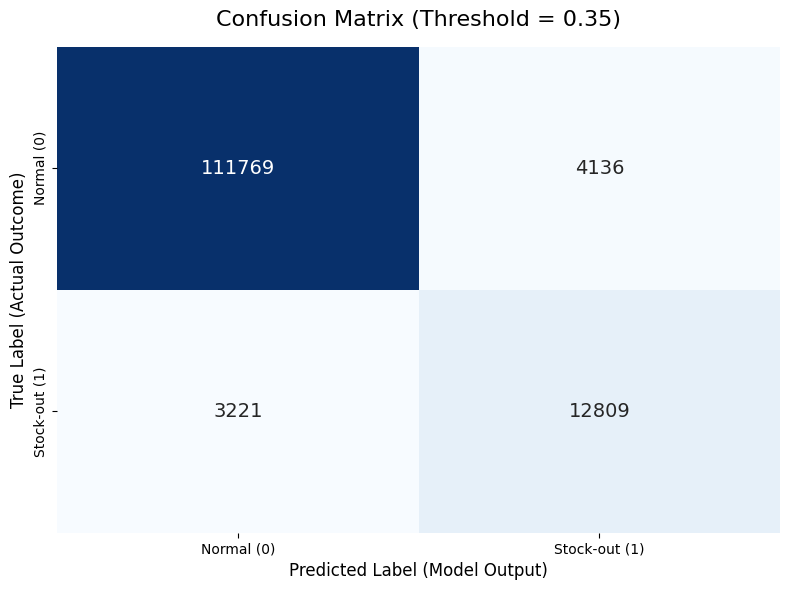

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score
)

print("Generating Comprehensive Evaluation Report for ML 4...")

# Ensure predictions exist using the optimal threshold
best_preds_class = (val_preds_proba >= best_thr).astype(int)

# 1. Core Metrics Calculation
acc = accuracy_score(y_val, best_preds_class)
roc_auc = roc_auc_score(y_val, val_preds_proba)
pr_auc = average_precision_score(y_val, val_preds_proba)
precision = precision_score(y_val, best_preds_class)
recall = recall_score(y_val, best_preds_class)
f1 = f1_score(y_val, best_preds_class)

print("-" * 50)
print("🌟 MODEL PERFORMANCE SUMMARY 🌟")
print("-" * 50)
print(f"Accuracy     : {acc:.4f}")
print(f"ROC-AUC      : {roc_auc:.4f}")
print(f"PR-AUC       : {pr_auc:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"F1-Score     : {f1:.4f}")
print("-" * 50)

# 2. Detailed Classification Report
print("\n📊 DETAILED CLASSIFICATION REPORT 📊")
print(classification_report(y_val, best_preds_class, digits=4))

# 3. Confusion Matrix Calculation
cm = confusion_matrix(y_val, best_preds_class)

# 4. Business Impact Analysis
total_cases = len(y_val)
actual_stockouts = sum(y_val)
predicted_stockouts = sum(best_preds_class)
correct_stockout_preds = cm[1, 1]
false_alarms = cm[0, 1]
missed_stockouts = cm[1, 0]

print("\n💼 BUSINESS IMPACT ANALYSIS 💼")
print("-" * 50)
print(f"Total Validation Cases       : {total_cases:,}")
print(f"Actual Stock-out Events      : {actual_stockouts:,}")
print(f"Predicted Stock-out Events   : {predicted_stockouts:,}")
print(f"Successfully Predicted (TP)  : {correct_stockout_preds:,} ({correct_stockout_preds/actual_stockouts*100:.1f}% of actual stock-outs)")
print(f"False Alarms (FP)            : {false_alarms:,} (Sent drivers when not needed)")
print(f"Missed Stock-outs (FN)       : {missed_stockouts:,} (Zones ran out of taxis unexpectedly)")
print("-" * 50)

# 5. Plotting Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Normal (0)', 'Stock-out (1)'],
            yticklabels=['Normal (0)', 'Stock-out (1)'],
            annot_kws={"size": 14})
plt.title(f'Confusion Matrix (Threshold = {best_thr:.2f})', fontsize=16, pad=15)
plt.xlabel('Predicted Label (Model Output)', fontsize=12)
plt.ylabel('True Label (Actual Outcome)', fontsize=12)
plt.tight_layout()
plt.show()

In [8]:

# ---------------------------------------------------------
# Save Model and Data to Google Drive
# ---------------------------------------------------------
model_save_path = '/content/drive/MyDrive/Full_Taxi_data/lgbm_stockout_model_ml4.pkl'
joblib.dump(final_model, model_save_path)
print(f"\n[1/2] Model successfully saved to: {model_save_path}")

data_save_path = '/content/drive/MyDrive/Full_Taxi_data/features_with_stockout_ml4.parquet'
df_master_stockout_pandas.to_parquet(data_save_path, index=False)
print(f"[2/2] Full dataset with predictions saved to: {data_save_path}")


[1/2] Model successfully saved to: /content/drive/MyDrive/Full_Taxi_data/lgbm_stockout_model_ml4.pkl
[2/2] Full dataset with predictions saved to: /content/drive/MyDrive/Full_Taxi_data/features_with_stockout_ml4.parquet
